In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

In [71]:
!pip install pypdf


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [90]:
from pypdf import PdfReader
def read_pdf(file_path):
    reader = PdfReader(file_path)
    text = ""
    for page in reader.pages:
        text += page.extract_text()
    return text

In [91]:
class ResumeState(TypedDict):
    resume: str
    role: str
    skills: List[str]
    score: int
    decision: str

In [92]:
def extract_skills(state: ResumeState):
    resume = state["resume"].lower()
    skills = []
    for skill in ["python","machine learning","deep learning","nlp","sql","opencv","fastapi","django","Go","gin"]:
        if skill in resume:
            skills.append(skill)
    return {"skills":skills}

In [93]:
def detect_role(state: ResumeState):
    resume = state["resume"].lower()
    if "machine learning" in resume or "deep learning" in resume:
        role = "ml"
    elif "backend" in resume or "api" in resume:
        role = "backend"
    else:
        role = "Data Science"
    return {"role":role}

In [94]:
def calculate_score(state: ResumeState):
    score = 0
    skills = state["skills"]
    role = state["role"]
    
    score += len(skills)*2

    if role == "ml":
        for s in ["python","machine learning","deep learning","nlp","opencv"]:
            if s in skills:
                score += 3
    elif role=="backend":
        for s in ["fastapi","python","django","gin","Go"]:
            if s in skills:
                score += 3
    else:
        for s in ["sql","python","machine learning"]:
            if s in skills:
                score += 3
    return {"score":score}

In [95]:
def decide(state: ResumeState):
    if state["score"] >=8:
        decision = "shortlist"
    else:
        decision = "reject"
    return {"decision":decision}

In [96]:
def shortlisted_node(state: ResumeState):
    return {"decision":"Shortlisted for "+ state["role"]}
def rejected_node(state: ResumeState):
    return {"decision":"Rejected"}

In [97]:
workflow = StateGraph(ResumeState)
workflow.add_node("role",detect_role)
workflow.add_node("extract",extract_skills)
workflow.add_node("score",calculate_score)
workflow.add_node("decide",decide)
workflow.add_node("shortlist",shortlisted_node)
workflow.add_node("reject",rejected_node)
workflow.set_entry_point("role")

In [98]:
workflow.add_edge("role","extract")
workflow.add_edge("extract","score")
workflow.add_edge("score","decide")

In [99]:
def route_decision(state: ResumeState):
    return state["decision"]

In [100]:
workflow.add_conditional_edges(
    "decide",
    route_decision,
    {
        "shortlist":"shortlist",
        "reject":"reject"
    }
)
workflow.add_edge("shortlist",END)
workflow.add_edge("reject",END)

In [101]:
app = workflow.compile()

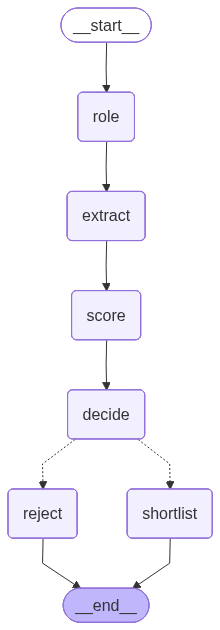

In [102]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [103]:
resume_text = read_pdf(r"C:\Users\Shraddha\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\644FD960732E378EB41036F8EAF9F9E16292AEA3\transfers\2026-09\Shraddha's__Resume_.pdf")
result = app.invoke({
    "resume":resume_text
})
print(result)

{'resume': 'Shraddha Tiwari\nGhaziabad |Email |LinkedIn |GitHub |Medium |Twitter (X)\nTechnical Skills\nLanguages: Python, Java, Golang, SQL, C\nML & AI : Supervised/Unsupervised Learning, Reinforcement Learning, Deep Learning(ANN, CNN, RNN\nand LSTM), Natural Language Processing,Transformer Fundamentals, Prompt Engineering, Embeddings, LLM-\nbased Applications,RAG, Vector Search Concepts, Computer Vision\nBackend : FastAPI, Pydantic, REST APIs, Go (net/http), JWT Authentication, Middleware, Protected Routes,\nRole-Based Access Control (RBAC), Password Hashing, API Testing\nFrameworks & Tools : Scikit-learn, Langchain, TensorFlow, OpenCV, Streamlit, Gin, Docker, AWS, JWT\n(golang-jwt), bcrypt\nDeveloper Tools : Git, Postman, Jupyter, Intellij IDEA, VS Code, Colab\nExperience\nGSSoC Contributor June 2025 – Aug 2025\n◦Built a price prediction system with tariff bracket suggestions, achieving 96.7% prediction accu-\nracy, and deployed it with an interactive Streamlit UI on Streamlit Cloud

In [88]:
result = app.invoke({
    "resume": "Python Machine Learning Deep Learning NLP"
})

print(result)

{'resume': 'Python Machine Learning Deep Learning NLP', 'role': 'ml', 'skills': ['python', 'machine learning', 'deep learning', 'nlp'], 'score': 20, 'decision': 'Shortlisted for ml'}


In [89]:
app.invoke({
 "resume":"Go FastAPI Django SQL REST API"
})

{'resume': 'Go FastAPI Django SQL REST API',
 'role': 'backend',
 'skills': ['sql', 'fastapi', 'django'],
 'score': 12,
 'decision': 'Shortlisted for backend'}